## Introducción

El objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajo con datos reales de TomTom Traffic Index y OECD Cities, que debo limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, valide que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:


# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
# Examinar la estructura de traffic
traffic.info()
traffic.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
1004461,ZAF,pretoria,2024-10-01 10:01:30.000,85.0,21.0,9.7,29.0,16.0,2024-09-24 10:16:30.001,13.690491,13.287302,0.403189
1004462,ZAF,pretoria,2024-10-01 09:01:30.000,68.1,20.0,6.7,23.0,15.0,2024-09-24 09:46:30.000,13.387203,12.983558,0.403646
1004463,ZAF,pretoria,2024-10-01 08:46:30.000,67.7,20.0,6.6,22.0,13.0,2024-09-24 08:46:30.000,13.311492,12.898624,0.412867


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo texto, hay que cambiarlos a tipo datetime para el analisis
- Tenemos que estandarizar el formato de escritura para columnas como `City`

In [ ]:
# Examinar la estructura de eco
eco.info()
eco.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
27,2024,mexico-city,Mexico,"21.111,00",3.2%,"22,30","22,10"
28,2024,lima,Peru,"13.472,00",6.5%,"19,70","11,20"
29,2024,montevideo,Uruguay,"26.176,00",8.4%,"11,20","1,80"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %` son de tipo texto, hay que cambiarlos a tipo entero o decimal para el analisis
- Tenemos que estandarizar el formato de escritura para columnas como `City`

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns = {"Country":"country",
                                    "City" : "city",
                                    "UpdateTimeUTC":"update_time_utc",
                                    "JamsDelay":"jams_delay",
                                    "TrafficIndexLive":"traffic_index_live",
                                    "JamsLengthInKms":"jams_length_in_Kms",
                                    "JamsCount":"jams_count",
                                    "TrafficIndexWeekAgo":"traffic_index_week_ago",
                                    "UpdateTimeUTCWeekAgo":"update_time_utc_week_ago",
                                    "TravelTimeLivePer10KmsMins":"travel_time_live_per_10Kms_mins",
                                    "TravelTimeHistoricPer10KmsMins":"travel_time_historic_per_10Kms_mins",
                                    "MinsDelay":"mins_delay"})

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_Kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10Kms_mins',
       'travel_time_historic_per_10Kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns = {"Year":"year",
                            "City":"city",
                            "Country":"country",
                            "City GDP/capita":"city_gdp_capita",
                            "Unemployment %":"unemployment_pct",
                            "PM2.5 (μg/m³)":"pm2_5_ug_m3",
                            "Population (M)":"population_m"})

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2_5_ug_m3', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors = 'coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors = 'coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_Kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10Kms_mins      1004464 non-null  fl

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2_5_ug_m3       30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2_5_ug_m3,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = (traffic['update_time_utc']).dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_Kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10Kms_mins,travel_time_historic_per_10Kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic["year"] == 2024 ].copy()
traffic_2024 = traffic_2024.reset_index()
eco_2024 = eco[eco["year"] == 2024 ].copy()
eco_2024 = eco_2024.reset_index()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,index,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_Kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10Kms_mins,travel_time_historic_per_10Kms_mins,mins_delay,year
0,302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
1,303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
2,304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
3,305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
4,306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,index,year,city,country,city_gdp_capita,unemployment_pct,pm2_5_ug_m3,population_m,population
0,15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
1,16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
2,17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
3,18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
4,19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcule los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(["city" , "country", "year"]).mean(numeric_only=True).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,index,jams_delay,traffic_index_live,jams_length_in_Kms,jams_count,traffic_index_week_ago,travel_time_live_per_10Kms_mins,travel_time_historic_per_10Kms_mins,mins_delay
0,a-coruna,ESP,2024,250666.5,17.935187,15.259774,2.198002,4.934405,15.821025,16.267977,15.493804,0.774172
1,aachen,DEU,2024,170126.0,26.732141,20.960314,3.892586,6.601832,21.874836,13.397861,12.604894,0.792968
2,aarhus,DNK,2024,240340.0,21.200616,16.575891,2.736736,6.109987,17.445227,15.219292,14.724016,0.495276
3,abu-dhabi,ARE,2024,1460.0,171.157315,13.902028,24.507380,47.268019,14.295209,9.829092,9.689328,0.139764
4,adana,TUR,2024,744567.0,83.864761,22.541040,11.827331,23.754620,22.508810,15.879694,14.749945,1.129749


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,index,jams_delay,traffic_index_live,jams_length_in_Kms,jams_count,traffic_index_week_ago,travel_time_live_per_10Kms_mins,travel_time_historic_per_10Kms_mins,mins_delay
221,mexico-city,MEX,2024,578368.0,2833.057892,34.218190,389.239265,594.969392,36.443813,21.809092,19.953550,1.855542
352,tokyo,JPN,2024,565312.0,2152.574357,36.805059,373.069734,518.809420,37.441779,22.443778,21.745626,0.698152
246,new-york,USA,2024,915542.0,2133.400000,28.210388,398.227892,544.474902,29.337407,18.505043,17.108691,1.396351
200,london,GBR,2024,424849.5,2050.703662,29.230166,287.632868,471.795554,30.827376,17.714139,16.388979,1.325160
211,manila,PHL,2024,656110.0,1741.493381,66.129402,246.858082,341.881205,68.628341,27.134629,24.664734,2.469894
...,...,...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,643091.5,4.651175,15.430809,0.712315,1.591384,15.975631,16.226009,15.592715,0.633294
363,uppsala,SWE,2024,739349.0,4.194486,13.939168,0.656368,1.349672,14.470460,15.746717,15.244916,0.501802
123,fujairah,ARE,2024,9332.0,4.025959,10.907719,0.731910,1.373006,10.938767,11.662590,11.467639,0.194951
12,almere,NLD,2024,583565.0,3.633523,6.290478,0.506362,1.064063,6.666082,9.467150,9.484694,-0.017544


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de Mexico

## 📋 Paso 5: Combinar datasets de tráfico y economía
### Objetivo:
Unir los dos DataFrames en un solo dataset con información unificada por ciudad.

## ¿Qué vas a hacer en este paso?
Crear versiones más pequeñas de ambos datasets con solo las columnas necesarias
Realizar un merge (unión) entre los datos de tráfico y los datos económicos
Verificar que la unión se haya realizado correctamente

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city', 'year', 'country', 'jams_delay', 'traffic_index_live', 'jams_length_in_Kms',
             'jams_count', 'travel_time_live_per_10Kms_mins', 'mins_delay']

right_cols = ['city', 'year', 'country', 'city_gdp_capita', 'unemployment_pct', 'population_m']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on = ['city','year'], how = 'inner')

# Mostrar las primeras 5 filas
merged.head()

,city,year,country_x,jams_delay,traffic_index_live,jams_length_in_Kms,jams_count,travel_time_live_per_10Kms_mins,mins_delay,country_y,city_gdp_capita,unemployment_pct,population_m
0,belo-horizonte,2024,BRA,263.047879,19.428946,44.038129,68.805422,18.304538,0.487228,Brazil,11124.0,9.5,6.1
1,bogota,2024,COL,1141.552364,37.614273,140.893564,230.566550,24.992185,1.699628,Colombia,11442.0,10.0,11.3
2,brasilia,2024,BRA,101.576326,11.258220,18.337133,27.280140,13.338658,0.193442,Brazil,16251.0,7.8,4.8
3,buenos-aires,2024,ARG,571.089593,17.756012,100.287844,137.359860,17.907916,0.416566,Argentina,18117.0,7.2,15.4
4,curitiba,2024,BRA,183.469274,14.954545,30.050044,46.898164,17.258700,0.139965,Brazil,12381.0,8.2,3.7


In [ ]:
#verificacion de duplicados en nuestro merged
merged[['city' , 'year']].duplicated().sum()

0


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

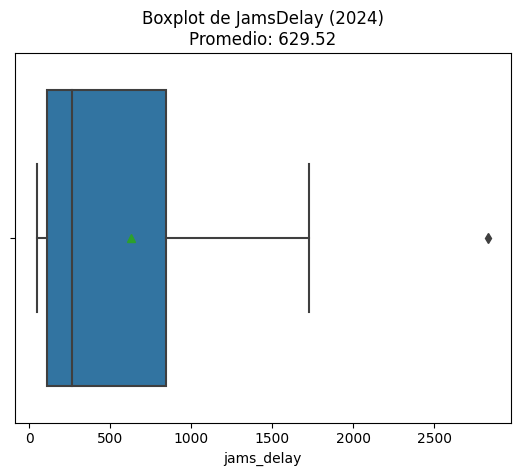

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data = merged, x = 'jams_delay', showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


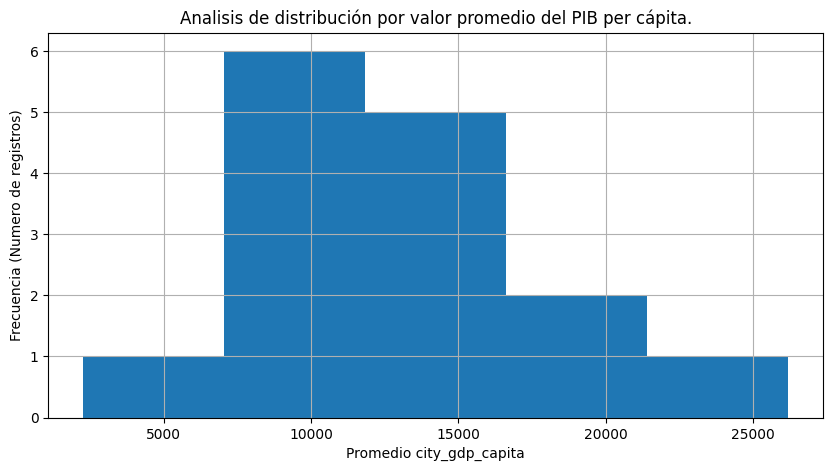

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged['city_gdp_capita'].hist(bins = 5, figsize = (10,5))

plt.title('Analisis de distribución por valor promedio del PIB per cápita.')
plt.xlabel('Promedio city_gdp_capita')
plt.ylabel('Frecuencia (Numero de registros)')
plt.show()

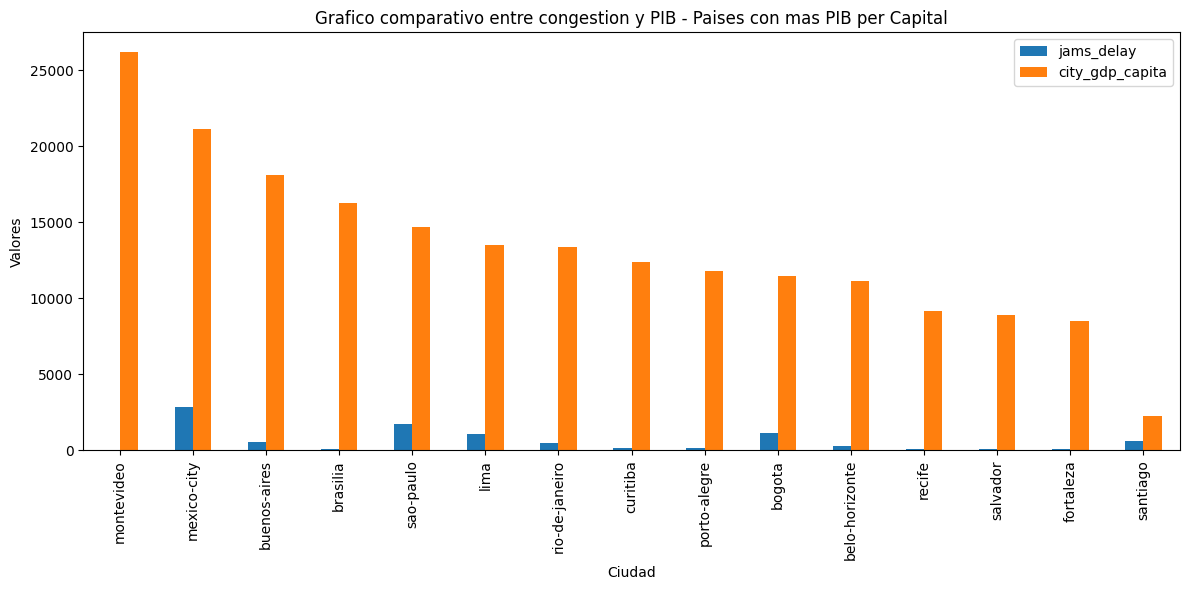

In [ ]:

# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.sort_values('city_gdp_capita', ascending=False).set_index('city').plot( kind = 'bar' , y=['jams_delay', 'city_gdp_capita'], figsize = (12,6))
plt.title('Grafico comparativo entre congestion y PIB - Paises con mas PIB per Capital')
plt.xlabel('Ciudad')
plt.ylabel('Valores')
plt.xticks(rotation=90)
plt.tight_layout() # Para que no se corten las etiquetas
plt.show()


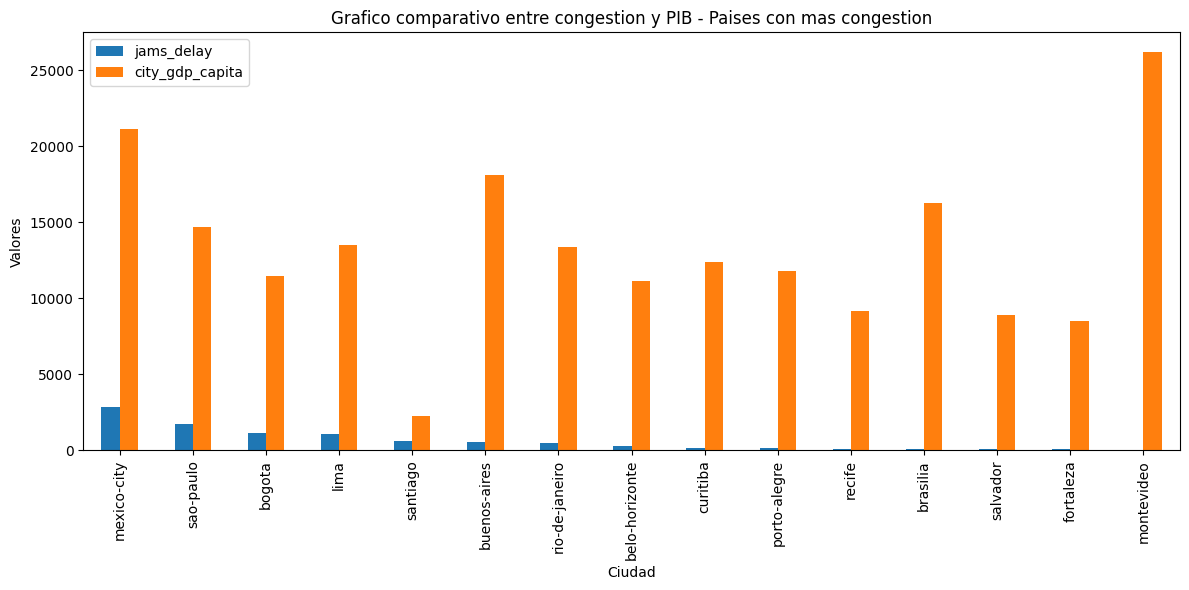

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.sort_values('jams_delay', ascending=False).set_index('city').plot( kind = 'bar' , y=['jams_delay', 'city_gdp_capita'], figsize = (12,6))
plt.title('Grafico comparativo entre congestion y PIB - Paises con mas congestion')
plt.xlabel('Ciudad')
plt.ylabel('Valores')
plt.xticks(rotation=90)
plt.tight_layout() # Para que no se corten las etiquetas
plt.show()

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

1. Comparando las dos ciudades con mayor PIB evidenciamos que montevideo tiene el mayor PIB pero no tiene congestion, en cambio Ciudad de mexico es la segunda ciudad con el mayor PIB y la primera con mayor congestion, no se encuentra ninguna relacion de estos dos factores, nos tocaria buscar otros factores como el tamaño de las ciudades, la cantidad de habitantes y tambien muy importante el PIB de ambas ciudades esta representado por que actividades economicas


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo


**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?

  - Comparando las dos ciudades con mayor PIB evidenciamos que montevideo tiene el mayor PIB pero no tiene congestion, en cambio Ciudad de mexico es la segunda ciudad con el mayor PIB y la primera con mayor congestion, no se encuentra ninguna relacion de estos dos factores, nos tocaria buscar otros factores como el tamaño de las ciudades, la cantidad de habitantes y tambien muy importante el PIB de ambas ciudades esta representado por que actividades economicas
  
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

  - Las variables claves fueron las ciudades, tiempos de viaje y PIB per capital ya que con estas podiamos tomas decisiones y hacer una comparativa clave

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.
  
  - El año analizado fue 2024, fueron 15 ciudades ('belo-horizonte' 'bogota' 'brasilia' 'buenos-aires' 'curitiba' 'fortaleza' 'lima' 'mexico-city' 'montevideo' 'porto-alegre' 'recife' 'rio-de-janeiro' 'salvador' 'santiago' 'sao-paulo') y 7 paises ('BRA' 'COL' 'ARG' 'PER' 'MEX' 'URY' 'CHL')

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).

  - Cambiamos los nombres de las columnas para tener todo en un mismo formato de escritura, adicional de utilizar pd.to_datetime para cambiar el tipo de dato a fechas para poder sacar el año posteriormente para nuestro analisis
  
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.

  - Ciudad y año fueron nuestras keys o claves de union de nuestros datasets ya que estaban estos datos en ambos y asi con el INNER manteniendo estas keys pudimos hacer el nalisis correspondiente
  
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

  - Como lo pedia el ejercicio hicimos un histograma, un boxplot y un grafico de barras, estos primeros graficos nos mostraron los valores extremos y la frecuencia de algunos datos pero el grafico de barras  nos da una comparativa clara de los paises donde vemos el PIB y la congestion vehicular donde si podemos sacar varias conclusiones

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
  
  - Realice dos graficos en donde cambie el orden de las variables para ver las ciudades con mayor PIB y la de mayor congestion, encontre que montevideo es la de mayor PIB y la que presenta menos congestion de todas las ciudades, como mencionaba hay que ver este PIB es representado a cual o cuales actividades economicas para que sea tan alto y tambien ver otros factores como poblacion dentro de montevideo y si es significativa entonces cuales son sus estrategias de desarrolo urbano y de desarrollo vial para que sean la que presente la menor congestion

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?
  
  - Bogota se posiciona decima en la tabla de PIB per capital y se posiciona tercera en ciudades con mayor congestion, es una prioridad para bogota invertir en nueva infraestrutura de transporte para mejorar los tiempo que pasan los bogotano en el transito  

In [ ]:
print(merged['city'].unique())
print(merged['country_x'].unique())

['belo-horizonte' 'bogota' 'brasilia' 'buenos-aires' 'curitiba'
 'fortaleza' 'lima' 'mexico-city' 'montevideo' 'porto-alegre' 'recife'
 'rio-de-janeiro' 'salvador' 'santiago' 'sao-paulo']
['BRA' 'COL' 'ARG' 'PER' 'MEX' 'URY' 'CHL']
